→ Control: 显示 PPMI_3104_MR_T1-anatomical_Br_20120904141724121_S103322_I330120.nii



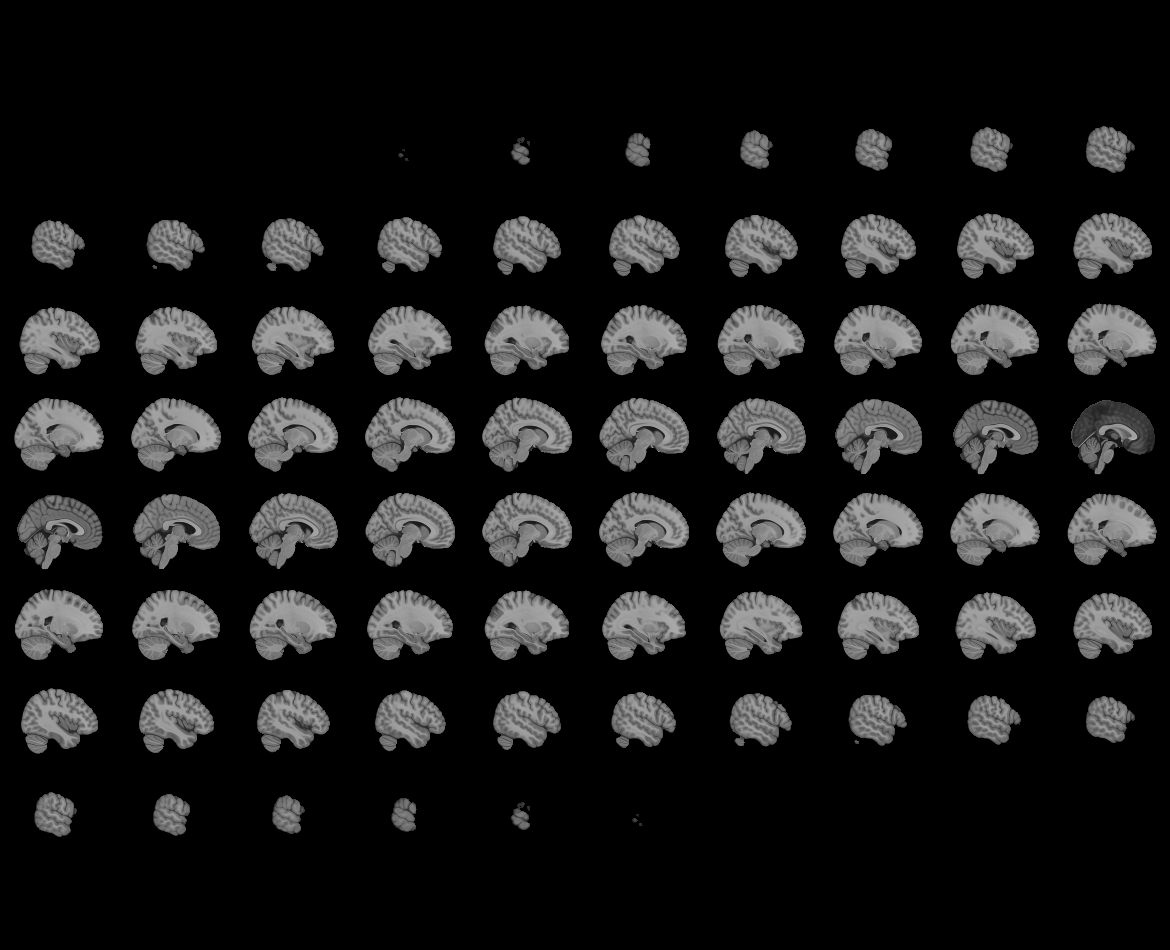
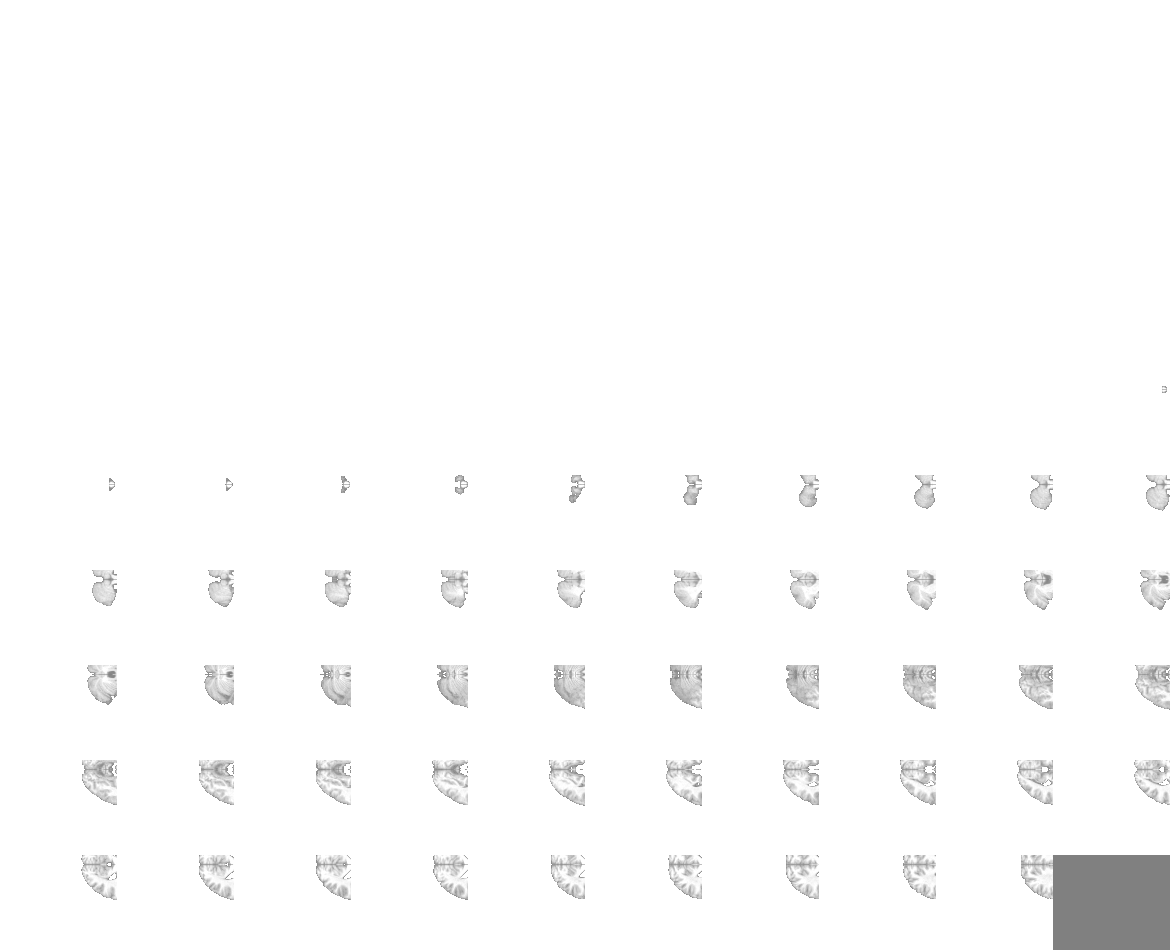

→ PD: 显示 PPMI_3102_MR_T1-anatomical_Br_20120911162206099_S103294_I333354.nii



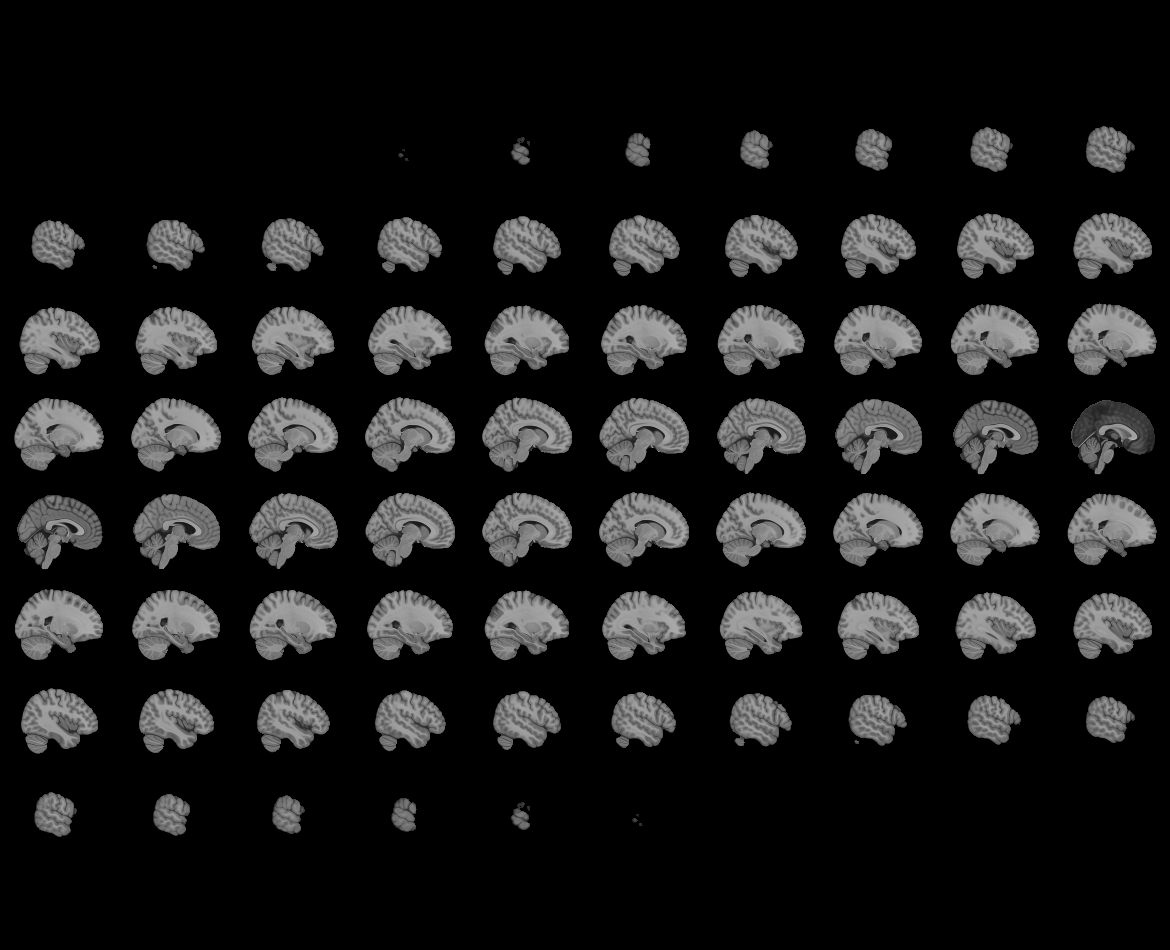
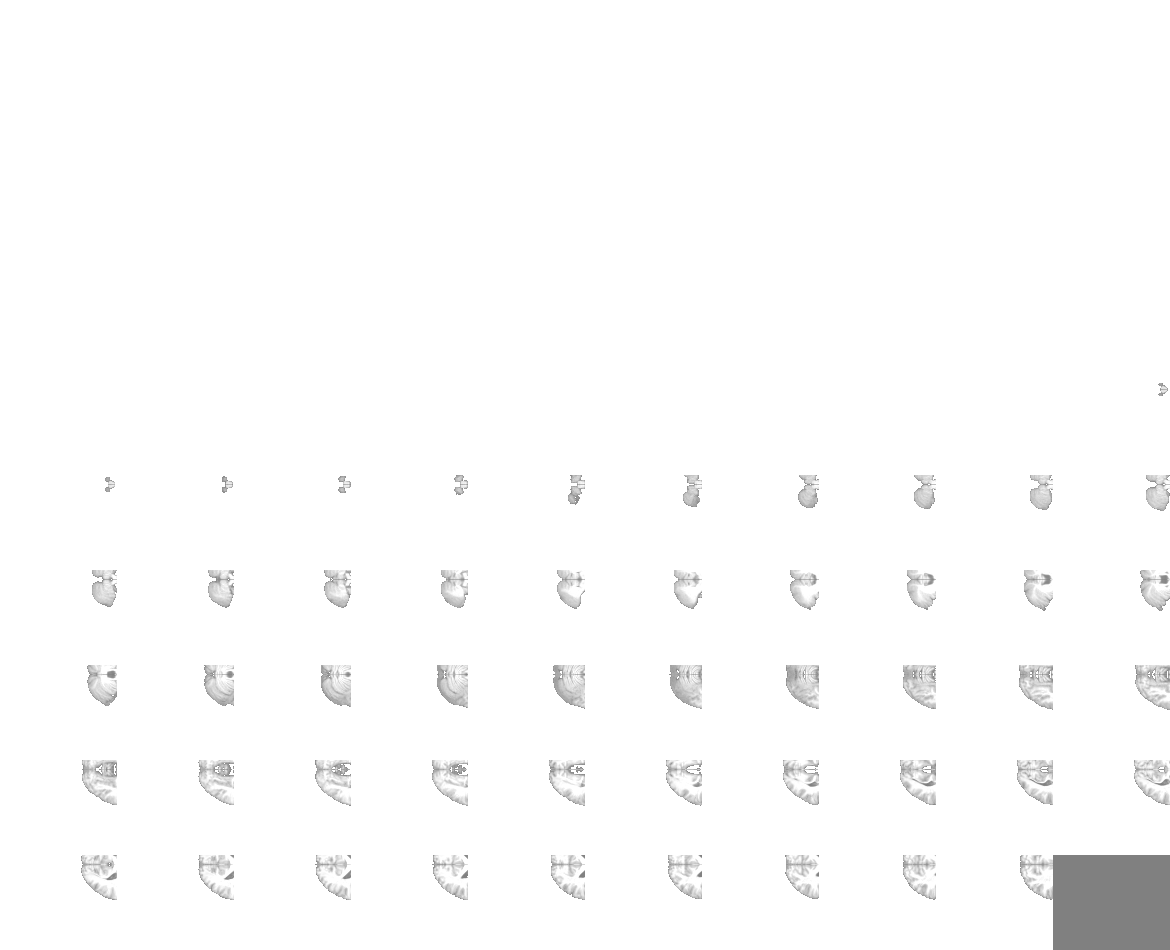

→ Prodromal: 显示 PPMI_14426_MR_T1-anatomical_Br_20161020185834039_S405053_I785358.nii



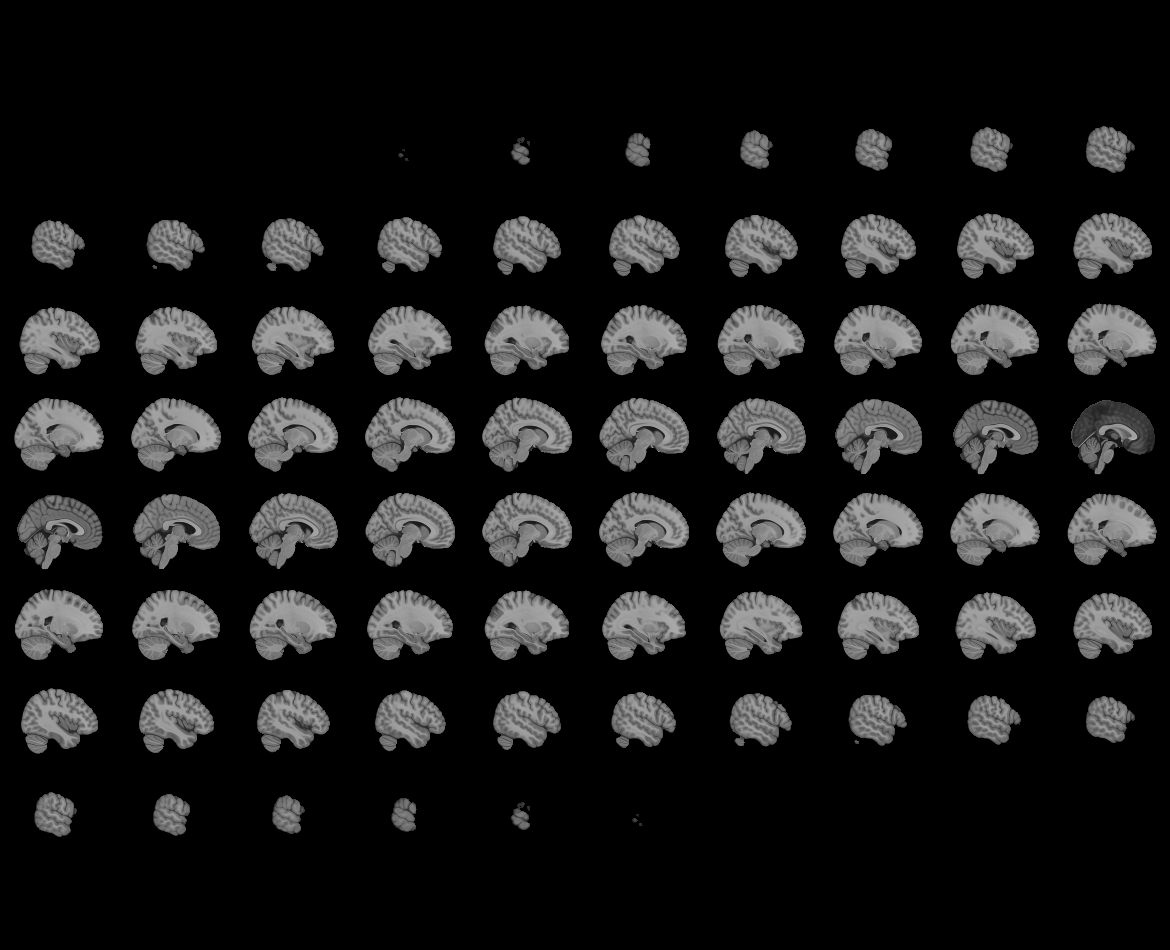
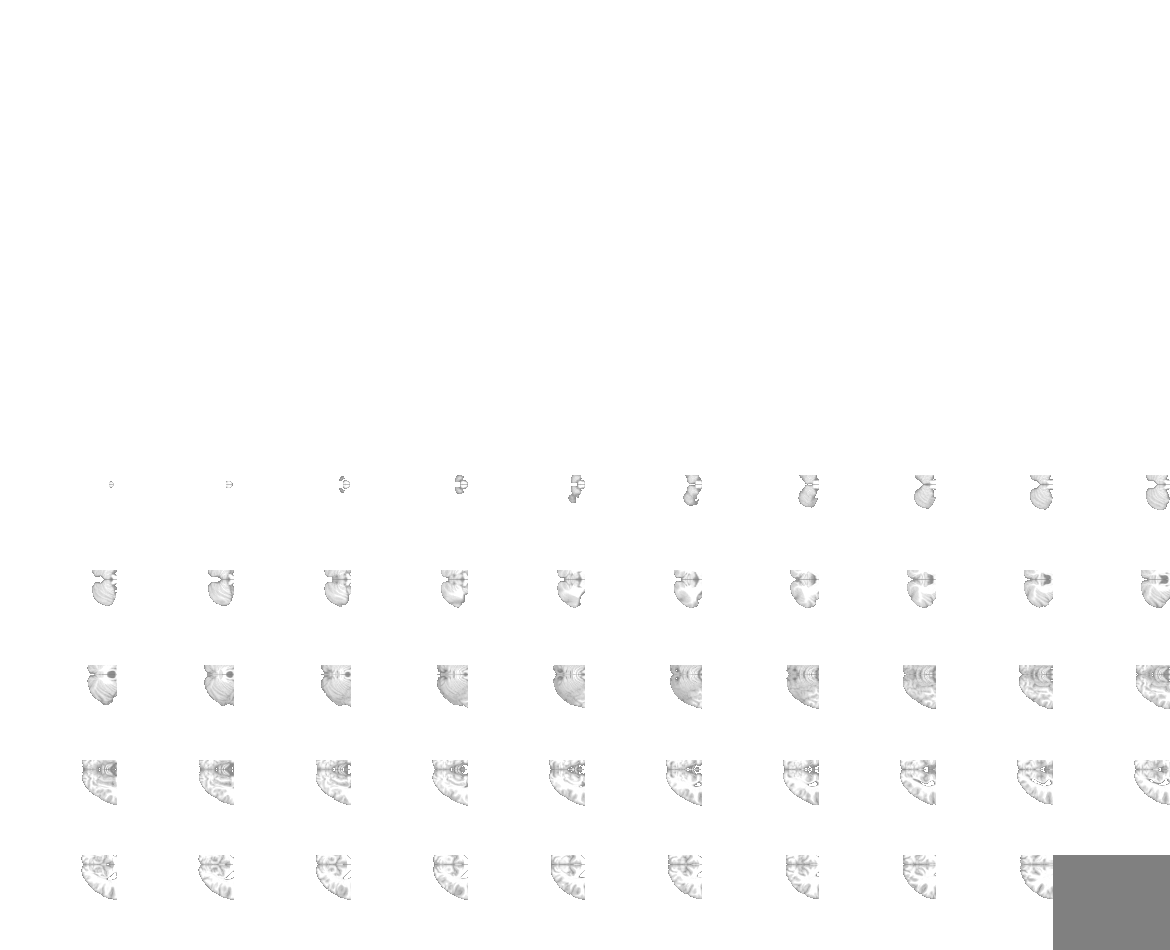

→ SWEDD: 显示 PPMI_3101_MR_T1-anatomical_Br_20140122132758838_S178931_I405842.nii



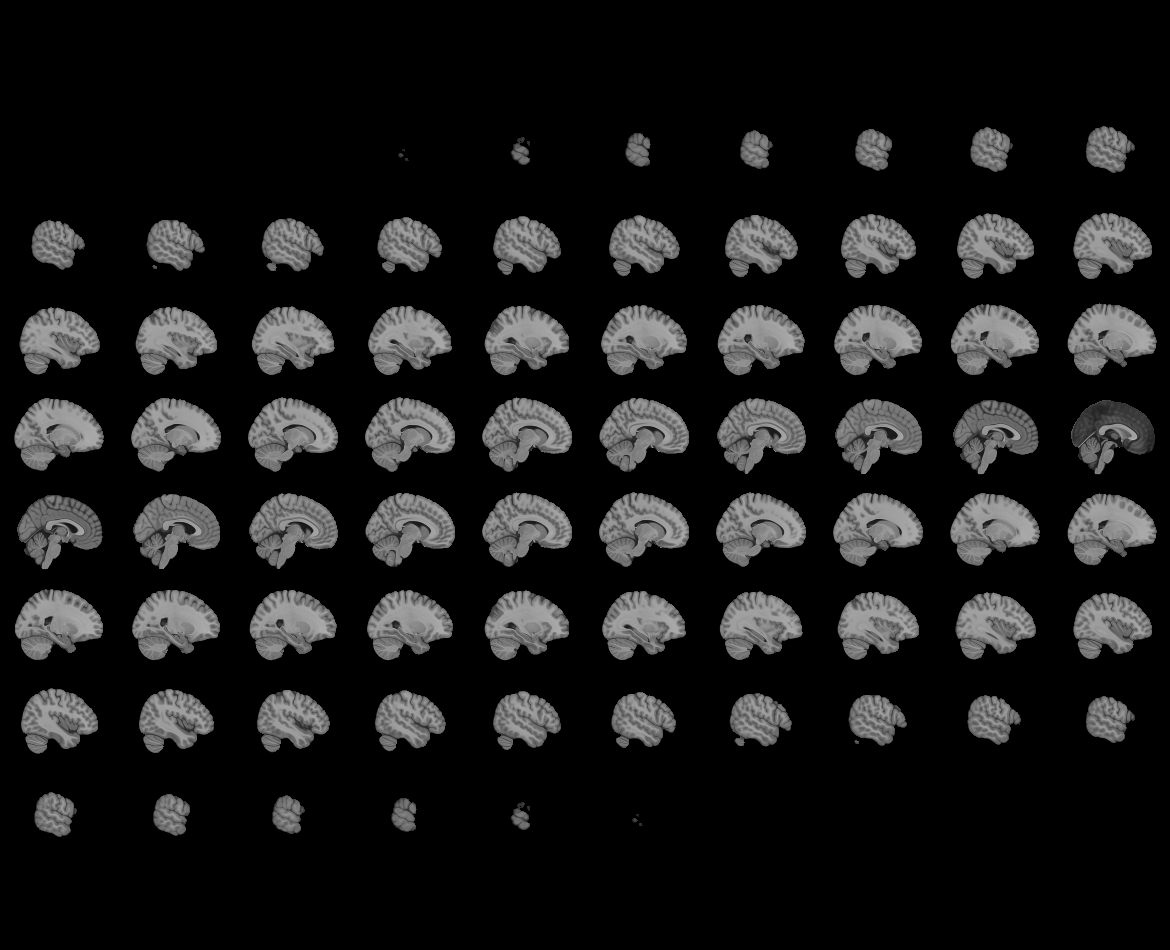
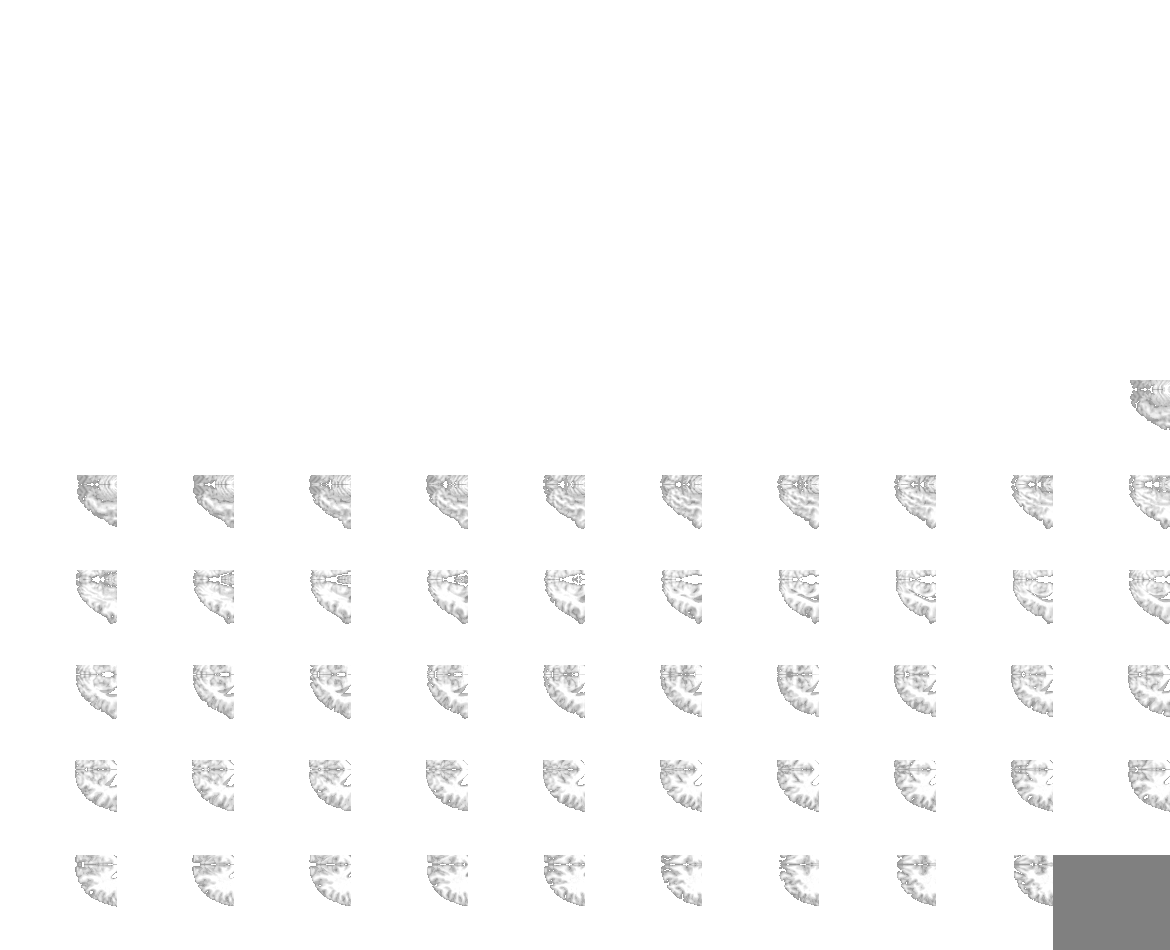

In [1]:
# --------------------------------------------
# 展示四个顶层分组目录里找到的第一个 NIfTI
# --------------------------------------------
from pathlib import Path
from nilearn import plotting as niplot
from IPython.display import display

ROOT     = Path(".")                          # 已在 /codeppmi/coce
GROUPS   = ["Control", "PD", "Prodromal", "SWEDD"]
EXTS     = ("*.nii", "*.nii.gz")              # 同时支持两种后缀

for g in GROUPS:
    # 1) 构造分组目录
    g_dir = ROOT / g
    if not g_dir.exists():
        print(f"[!] 目录不存在：{g_dir}, 已跳过")
        continue

    # 2) 搜索当前目录下第一个 NIfTI
    nii_list = []
    for ext in EXTS:
        nii_list += sorted(g_dir.glob(ext))    # 不递归，只在该目录搜索

    if not nii_list:
        print(f"[!] {g} 目录下未找到 .nii 文件")
        continue

    target = nii_list[0]
    print(f"→ {g}: 显示 {target.name}")

    # 3) 弹出交互式 3-D 浏览器
    view = niplot.view_img(
        str(target),
        cmap="gray",
        black_bg=True,
        title=g                                # 浏览器左上角标题
    )
    display(view)




Group           | Best Coordinates (x, y, z)     | Filename
--------------------------------------------------------------------------------
Control         | (93.31, 123.93, 98.00)         | PPMI_3104_MR_T1-anatomical_Br_20120904141724121_S103322_I330120.nii


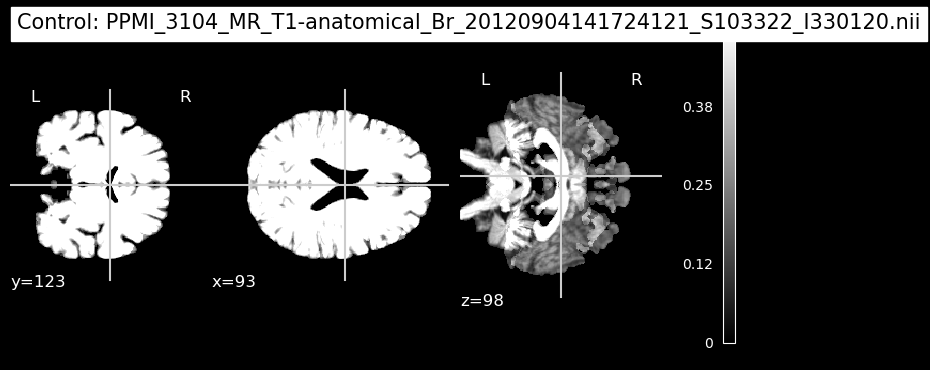

PD              | (88.74, 121.36, 98.00)         | PPMI_3102_MR_T1-anatomical_Br_20120911162206099_S103294_I333354.nii


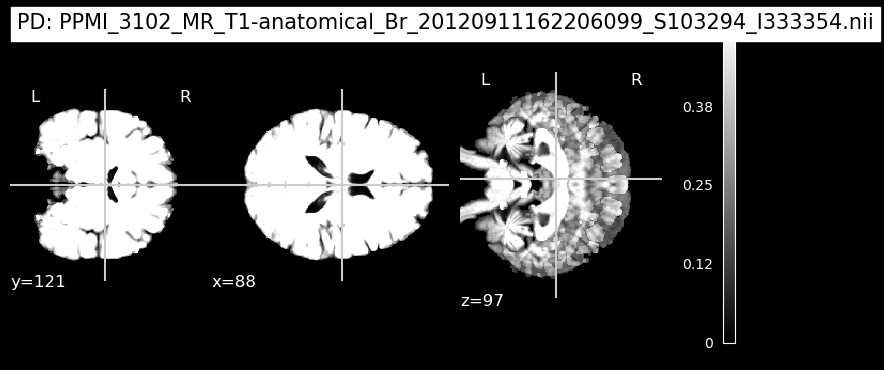

Prodromal       | (88.59, 119.42, 98.00)         | PPMI_14426_MR_T1-anatomical_Br_20161020185834039_S405053_I785358.nii


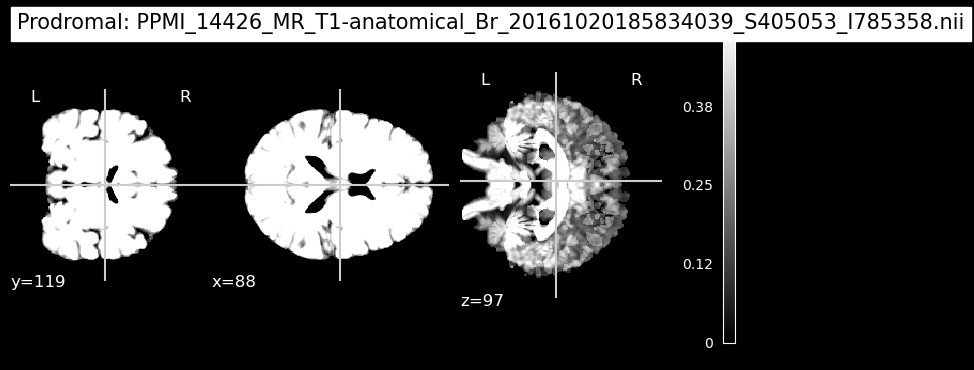

SWEDD           | (77.29, 119.58, 98.00)         | PPMI_3101_MR_T1-anatomical_Br_20140122132758838_S178931_I405842.nii


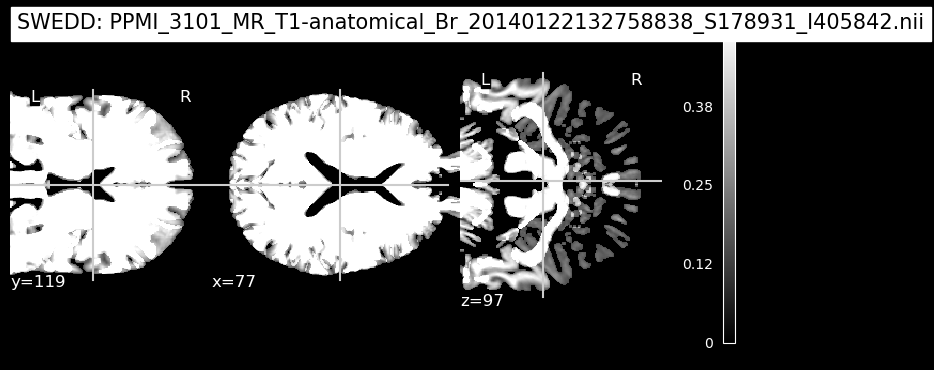

In [2]:
from pathlib import Path
from nilearn import plotting, image
import matplotlib.pyplot as plt

ROOT      = Path(".")                         # 你的数据根目录
GROUPS    = ["Control", "PD", "Prodromal", "SWEDD"]
EXTS      = ("*.nii", "*.nii.gz")

print(f"{'Group':<15} | {'Best Coordinates (x, y, z)':<30} | {'Filename'}")
print("-" * 80)

for g in GROUPS:
    g_dir = ROOT / g
    if not g_dir.exists():
        continue

    # 1) 找到该组第一个 NIfTI 文件
    nii_list = []
    for ext in EXTS:
        nii_list += sorted(g_dir.glob(ext))
    
    if not nii_list:
        continue

    target = nii_list[0]
    
    # 2) 加载图像
    # nilearn 需要先加载 img 对象才能计算坐标
    img = image.load_img(str(target))

    # 3) 自动计算“最清晰”的切片坐标
    # find_xyz_cut_coords 会扫描图像强度，自动找到大脑结构的中心点
    best_coords = plotting.find_xyz_cut_coords(img)
    
    # 打印结果
    # 坐标保留2位小数显示
    coords_str = f"({best_coords[0]:.2f}, {best_coords[1]:.2f}, {best_coords[2]:.2f})"
    print(f"{g:<15} | {coords_str:<30} | {target.name}")

    # 4) 可视化 (使用 plot_anat 适合解剖结构)
    # display_mode='ortho' 会同时显示三个视角 (Axial, Sagittal, Coronal)
    plotting.plot_anat(
        img,
        cut_coords=best_coords,       # 使用计算出的最佳坐标
        title=f"{g}: {target.name}",
        display_mode='ortho',
        draw_cross=True,              # 显示十字准星定位
        annotate=True,                # 显示 L/R 标注
        dim=-1                        # 自动调整背景对比度
    )
    
    # 在 Notebook 中显式展示图像
    plotting.show()